In [1]:
pip install pandas numpy matplotlib seaborn plotly geopandas kaleido

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 790.9 kB/s eta 0:00:29
    --------------------------------------- 0.5/22.9 MB 790.9 kB/s eta 0:00:29
    --------------------------------------- 0.5/22.9 MB 790.9 kB/s eta 0:00:29
   - -------------------------------------- 0.8/22.9 MB 563.5 kB/s eta 0:00:40
   - -------------------------------------- 0.8/22.9 MB 563.5 kB/s eta 0:00:40
   - -------------------------------------- 1.0/22.9 MB 536.1 kB/s eta 0:00:41
   - -------------------------------------- 1.0/22.9 MB 536.1 kB/s eta 0:00:41
   - -------------------------------------- 1.0/22.9 MB 536.1 kB/s eta 0:00:41
   -- ------------

### Data Cleaning

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('data/netflix_titles.csv')

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (8807, 12)

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Dtypes:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [19]:
#Fixing missing values: missing text to unknown

df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Not Rated')

# Drop the handful of rows missing date or year
df.dropna(subset=['date_added', 'release_year'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Nulls after cleaning:", df.isnull().sum().sum())

Nulls after cleaning: 3


In [20]:
# ── Date parsing ──────────────────────────────────────────────────────────────
df['date_added']   = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added']   = df['date_added'].dt.year.astype('Int64')
df['month_added']  = df['date_added'].dt.month
df['month_name']   = df['date_added'].dt.strftime('%b')

# ── Duration parsing ──────────────────────────────────────────────────────────
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit']  = df['duration'].str.extract(r'([A-Za-z]+)')

# ── Lag: how old was content when added? ─────────────────────────────────────
df['content_lag_years'] = df['year_added'] - df['release_year']
df['content_lag_years'] = df['content_lag_years'].clip(lower=0)   # remove bad rows

print(df[['title','duration','duration_value','duration_unit','content_lag_years']].head(8))

                              title   duration  duration_value duration_unit  \
0              Dick Johnson Is Dead     90 min            90.0           min   
1                     Blood & Water  2 Seasons             2.0       Seasons   
2                         Ganglands   1 Season             1.0        Season   
3             Jailbirds New Orleans   1 Season             1.0        Season   
4                      Kota Factory  2 Seasons             2.0       Seasons   
5                     Midnight Mass   1 Season             1.0        Season   
6  My Little Pony: A New Generation     91 min            91.0           min   
7                           Sankofa    125 min           125.0           min   

   content_lag_years  
0                  1  
1                  0  
2                  0  
3                  0  
4                  0  
5                  0  
6                  0  
7                 28  


In [21]:
# ── Genres: "Action, Sci-Fi" → one row per genre ─────────────────────────────
df_genres = (df.assign(genre=df['listed_in'].str.split(', '))
               .explode('genre'))
df_genres['genre'] = df_genres['genre'].str.strip()

# ── Countries: "US, India" → one row per country ────────────────────────────
df_countries = (df.assign(country_clean=df['country'].str.split(', '))
                  .explode('country_clean'))
df_countries['country_clean'] = df_countries['country_clean'].str.strip()
df_countries = df_countries[df_countries['country_clean'] != 'Unknown']

# ── Cast: one row per actor ───────────────────────────────────────────────────
df_cast = (df[df['cast'] != 'Unknown']
           .assign(actor=df['cast'].str.split(', '))
           .explode('actor'))
df_cast['actor'] = df_cast['actor'].str.strip()

print(f"Genre rows: {len(df_genres):,}")
print(f"Country rows: {len(df_countries):,}")
print(f"Cast rows: {len(df_cast):,}")

Genre rows: 19,303
Country rows: 10,005
Cast rows: 64,057


In [23]:
movies = df[df['type'] == 'Movie'].copy()
shows  = df[df['type'] == 'TV Show'].copy()

print("=== DATASET SUMMARY ===")
print(f"Total titles       : {len(df):,}")
print(f"Movies             : {len(movies):,} ({len(movies)/len(df)*100:.1f}%)")
print(f"TV Shows           : {len(shows):,} ({len(shows)/len(df)*100:.1f}%)")
print(f"Year range added   : {df['year_added'].min()} – {df['year_added'].max()}")
print(f"Unique countries   : {df_countries['country_clean'].nunique()}")
print(f"Unique genres      : {df_genres['genre'].nunique()}")
print(f"\nMovie runtime (min):\n{movies['duration_value'].describe()}")
print(f"\nTV Show seasons:\n{shows['duration_value'].describe()}")

=== DATASET SUMMARY ===
Total titles       : 8,797
Movies             : 6,131 (69.7%)
TV Shows           : 2,666 (30.3%)
Year range added   : 2008 – 2021
Unique countries   : 127
Unique genres      : 42

Movie runtime (min):
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

TV Show seasons:
count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64


### Visualizations


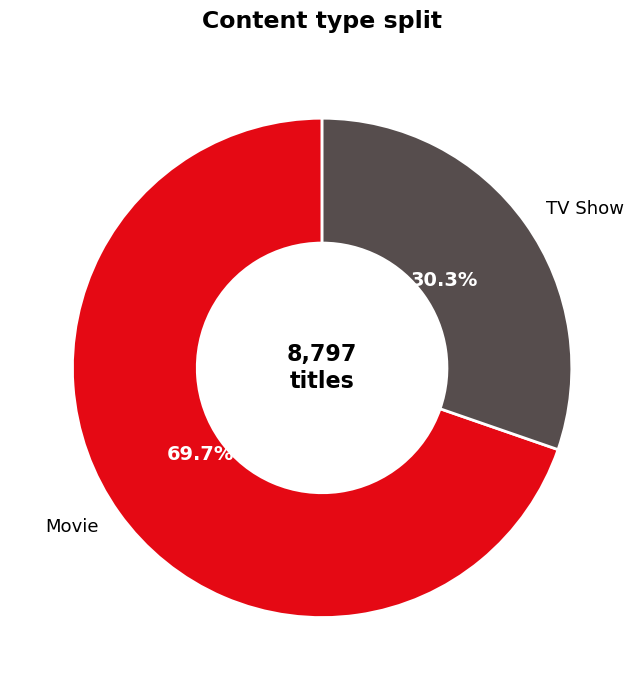

In [24]:
# Donut Chart (Movies vs TV)
type_counts = df['type'].value_counts()
colors = ['#E50914', '#564d4d']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    type_counts, labels=type_counts.index,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    colors=colors, textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(14); at.set_fontweight('bold'); at.set_color('white')
ax.set_title('Content type split', fontsize=17, fontweight='bold', pad=20)
centre_text = ax.text(0, 0, f'{len(df):,}\ntitles', ha='center',
                      va='center', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_donut.png', dpi=150, bbox_inches='tight')
plt.show()

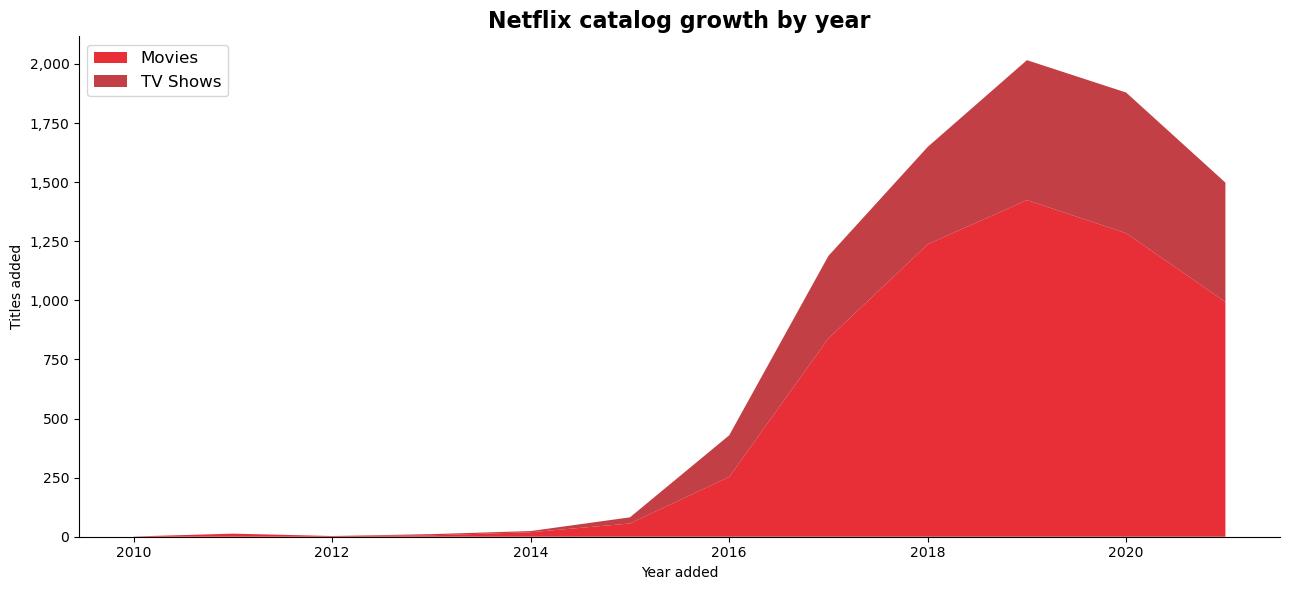

In [25]:
 # Stacked Area Chart (Catalog growth)
growth = (df.groupby(['year_added', 'type'])
            .size().unstack(fill_value=0)
            .loc[2010:2021])

fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(growth.index, growth['Movie'], growth['TV Show'],
             labels=['Movies', 'TV Shows'],
             colors=['#E50914', '#B81D24'], alpha=0.85)
ax.set_title('Netflix catalog growth by year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year added'); ax.set_ylabel('Titles added')
ax.legend(loc='upper left', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('charts/02_area_growth.png', dpi=150, bbox_inches='tight')
plt.show()

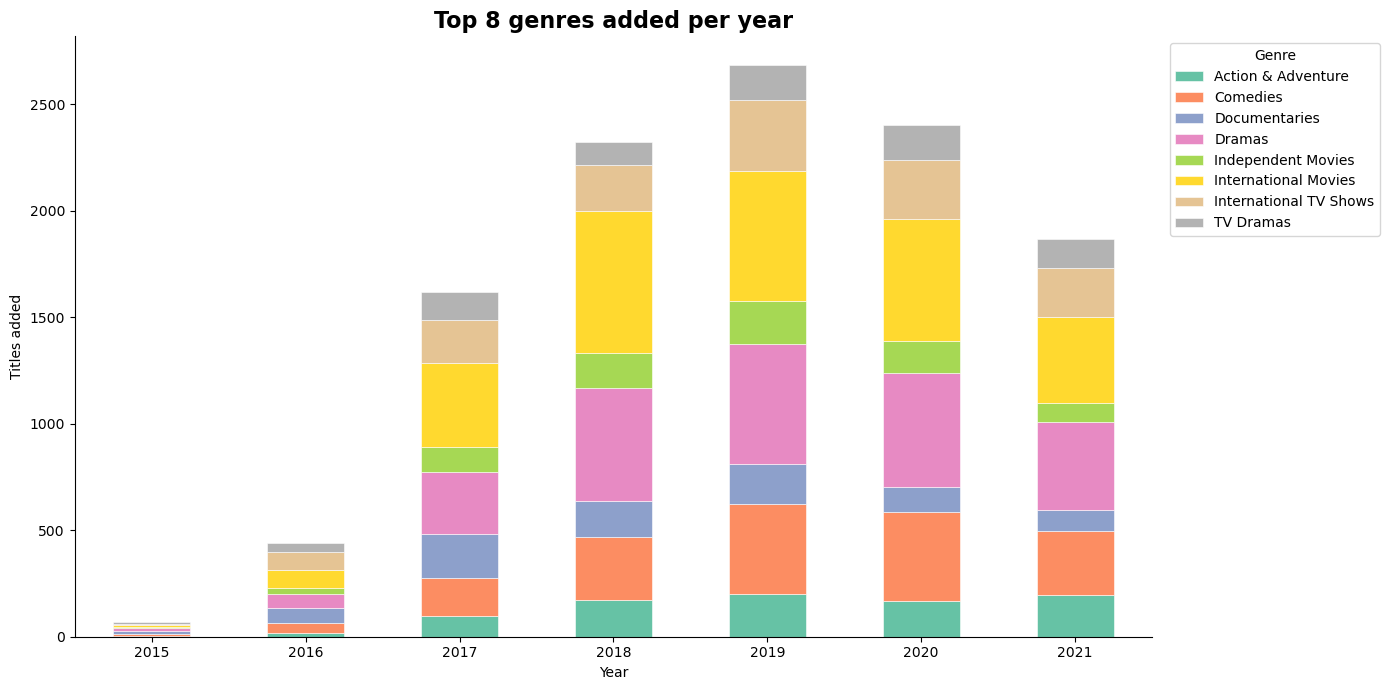

In [26]:
# Stacked Bar (Top 8 genres by year)
top8 = df_genres['genre'].value_counts().head(8).index.tolist()
genre_year = (df_genres[df_genres['genre'].isin(top8)]
              .groupby(['year_added', 'genre'])
              .size().unstack(fill_value=0)
              .loc[2015:2021])

palette = sns.color_palette('Set2', 8)
genre_year.plot(kind='bar', stacked=True, color=palette, figsize=(14, 7), edgecolor='white', linewidth=0.4)
plt.title('Top 8 genres added per year', fontsize=16, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Titles added')
plt.legend(title='Genre', bbox_to_anchor=(1.01, 1), fontsize=10)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('charts/03_stacked_genres.png', dpi=150, bbox_inches='tight')
plt.show()

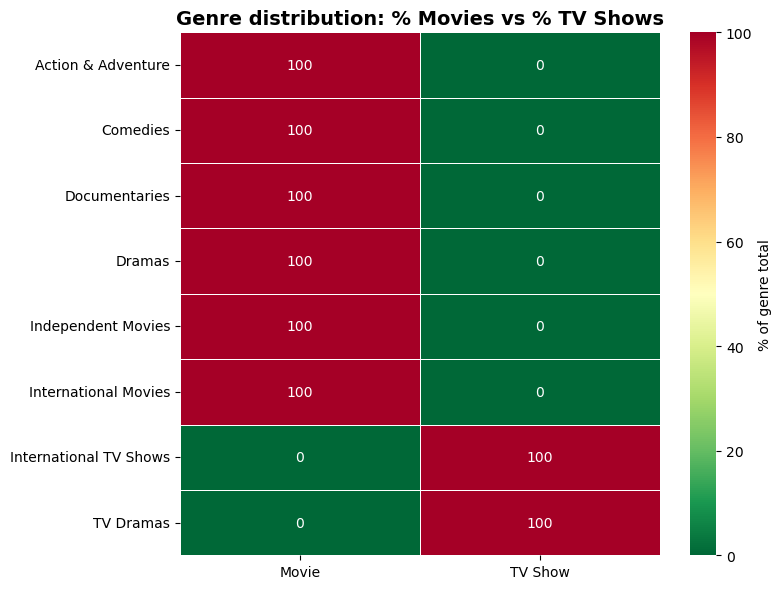

In [27]:
# Heatmap (Genre × Type matrix)
# Which genres lean Movie vs TV?
genre_type = (df_genres[df_genres['genre'].isin(top8)]
              .groupby(['genre', 'type'])
              .size().unstack(fill_value=0))
genre_type['Movie_%'] = genre_type['Movie'] / genre_type.sum(axis=1) * 100
genre_type_pct = genre_type[['Movie', 'TV Show']]

# Normalize to % of row total
genre_type_norm = genre_type_pct.div(genre_type_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(genre_type_norm, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of genre total'})
ax.set_title('Genre distribution: % Movies vs % TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/04_heatmap_genre_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Choropleth Map (Interactive)
country_counts = (df_countries['country_clean']
                  .value_counts().reset_index())
country_counts.columns = ['country', 'count']

fig = px.choropleth(
    country_counts,
    locations='country', locationmode='country names',
    color='count',
    color_continuous_scale='Reds',
    range_color=(1, country_counts['count'].quantile(0.95)),
    title='Netflix content production volume by country',
    labels={'count': 'Titles'},
    hover_name='country',
    hover_data={'count': True}
)
fig.update_layout(
    title_font_size=17,
    geo=dict(showframe=False, showcoastlines=True,
             projection_type='natural earth'),
    coloraxis_colorbar=dict(title='Titles', thickness=14)
)
fig.write_html('charts/05_choropleth.html')
fig.show()

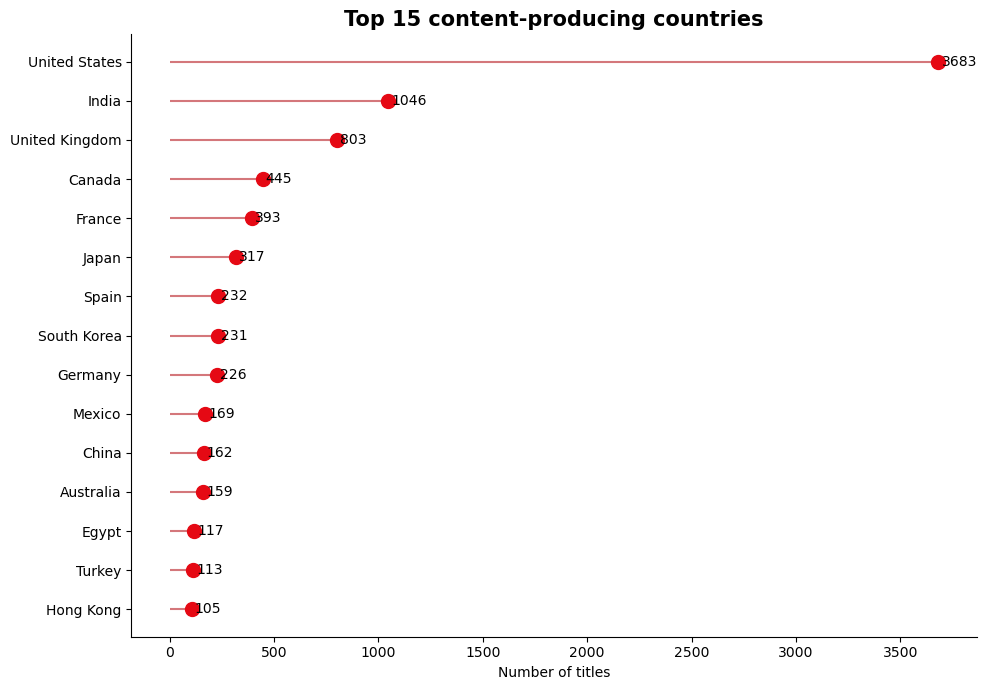

In [30]:
# Lollipop Chart (Top 15 countries)
top15 = country_counts.head(15).sort_values('count')

fig, ax = plt.subplots(figsize=(10, 7))
ax.hlines(y=top15['country'], xmin=0, xmax=top15['count'],
          color='#B81D24', linewidth=1.5, alpha=0.6)
ax.plot(top15['count'], top15['country'], 'o',
        color='#E50914', markersize=10, zorder=3)
for _, row in top15.iterrows():
    ax.text(row['count'] + 15, row['country'], str(row['count']),
            va='center', fontsize=10)
ax.set_title('Top 15 content-producing countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of titles'); ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.savefig('charts/06_lollipop_countries.png', dpi=150, bbox_inches='tight')
plt.show()

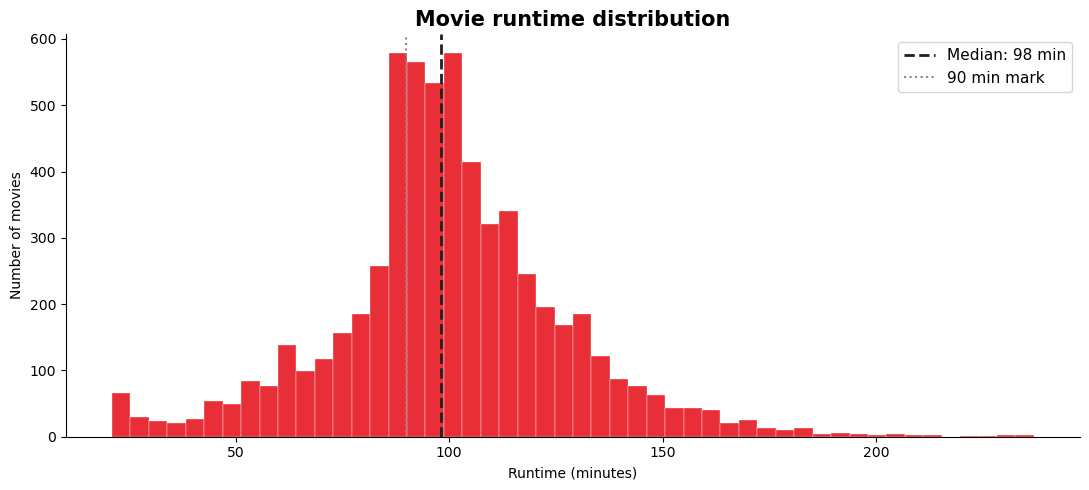

In [31]:
# Histogram (Movie runtime)
movie_runtime = movies[(movies['duration_value'] > 20) &
                        (movies['duration_value'] < 240)]['duration_value']

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(movie_runtime, bins=50, color='#E50914', edgecolor='white',
        linewidth=0.3, alpha=0.85)
ax.axvline(movie_runtime.median(), color='#221F1F', linestyle='--',
           linewidth=2, label=f'Median: {movie_runtime.median():.0f} min')
ax.axvline(90, color='#888', linestyle=':', linewidth=1.5, label='90 min mark')
ax.set_title('Movie runtime distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Runtime (minutes)'); ax.set_ylabel('Number of movies')
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('charts/07_histogram_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

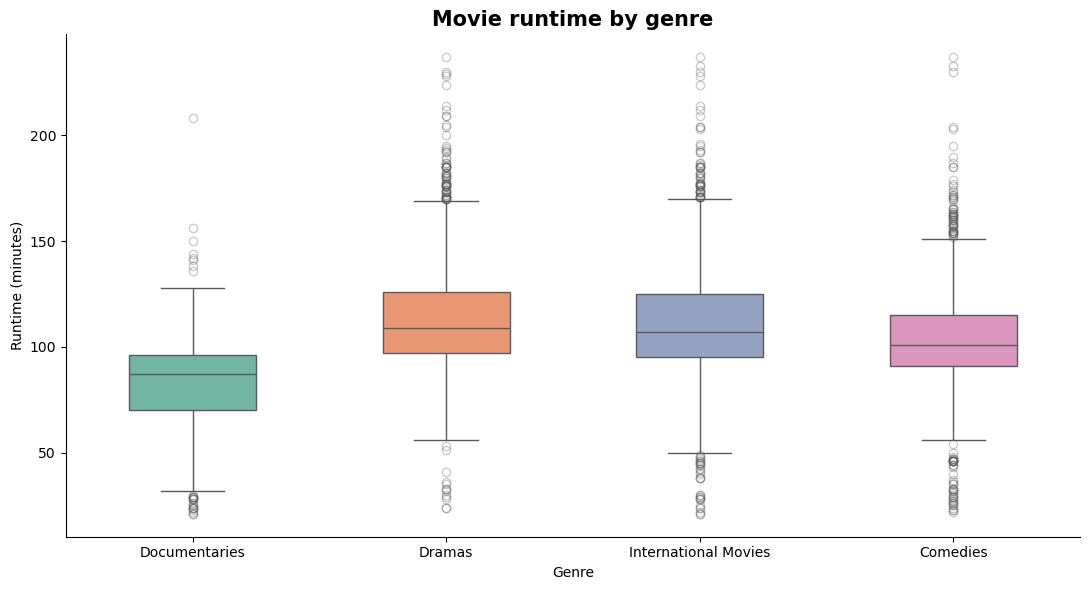

In [32]:
# Box Plot (Runtime by top genre)
top5_genres = df_genres['genre'].value_counts().head(5).index.tolist()
genre_runtime = (df_genres[(df_genres['genre'].isin(top5_genres)) &
                            (df_genres['type'] == 'Movie') &
                            (df_genres['duration_value'] > 20) &
                            (df_genres['duration_value'] < 240)])

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=genre_runtime, x='genre', y='duration_value',
            palette='Set2', width=0.5, flierprops={'alpha': 0.3},
            ax=ax)
ax.set_title('Movie runtime by genre', fontsize=15, fontweight='bold')
ax.set_xlabel('Genre'); ax.set_ylabel('Runtime (minutes)')
sns.despine()
plt.tight_layout()
plt.savefig('charts/08_boxplot_runtime_genre.png', dpi=150, bbox_inches='tight')
plt.show()

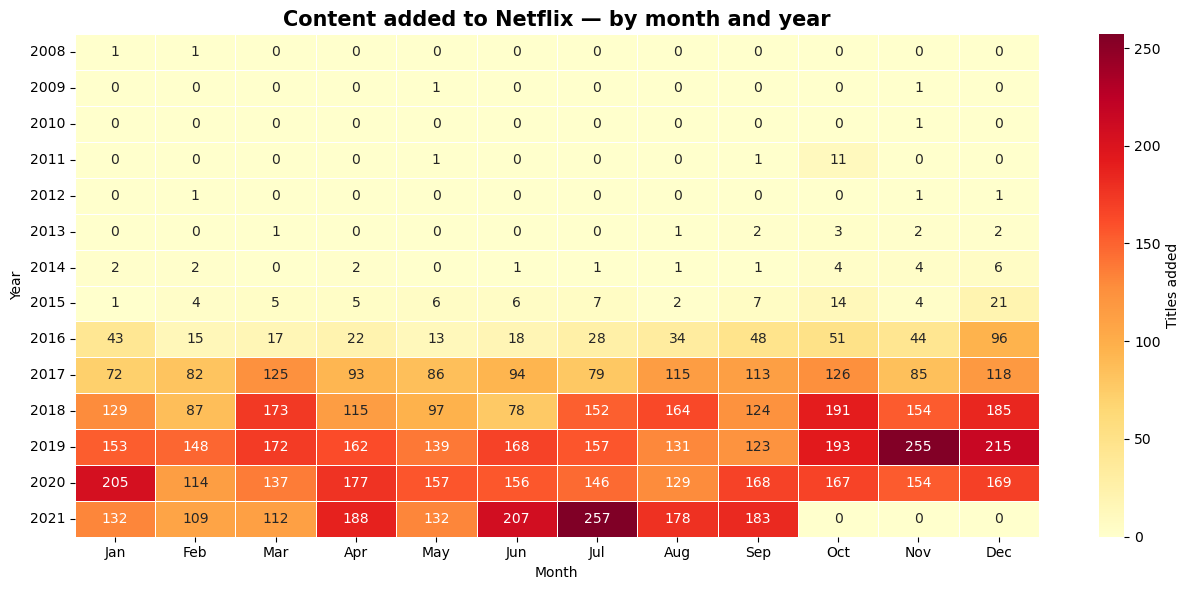

In [33]:
 # Calendar Heatmap (Content added by month/year)
monthly = (df.groupby(['year_added', 'month_added'])
             .size().reset_index(name='count'))
pivot = monthly.pivot(index='year_added', columns='month_added', values='count').fillna(0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Titles added'})
ax.set_title('Content added to Netflix — by month and year', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('charts/09_calendar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

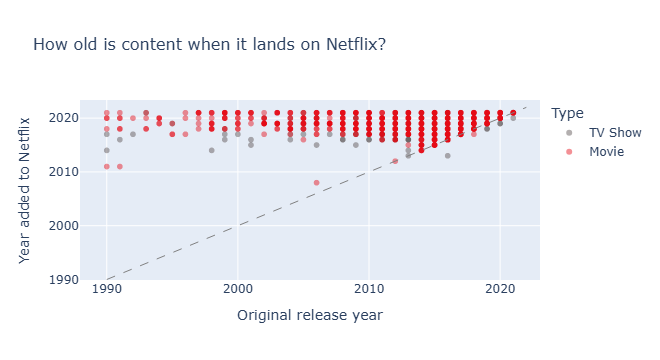

In [34]:
# Scatter Plot (Release year vs Year added)
sample = df[(df['release_year'] >= 1990) &
            (df['year_added'].notna())].sample(min(2000, len(df)), random_state=42)

fig = px.scatter(
    sample, x='release_year', y='year_added',
    color='type', opacity=0.45, size_max=6,
    color_discrete_map={'Movie': '#E50914', 'TV Show': '#564d4d'},
    labels={'release_year': 'Original release year',
            'year_added': 'Year added to Netflix'},
    title='How old is content when it lands on Netflix?',
    hover_data=['title', 'type', 'content_lag_years']
)
fig.add_shape(type='line', x0=1990, x1=2022, y0=1990, y1=2022,
              line=dict(color='gray', width=1, dash='dash'))
fig.update_layout(title_font_size=16, legend_title='Type')
fig.write_html('charts/10_scatter_lag.html')
fig.show()

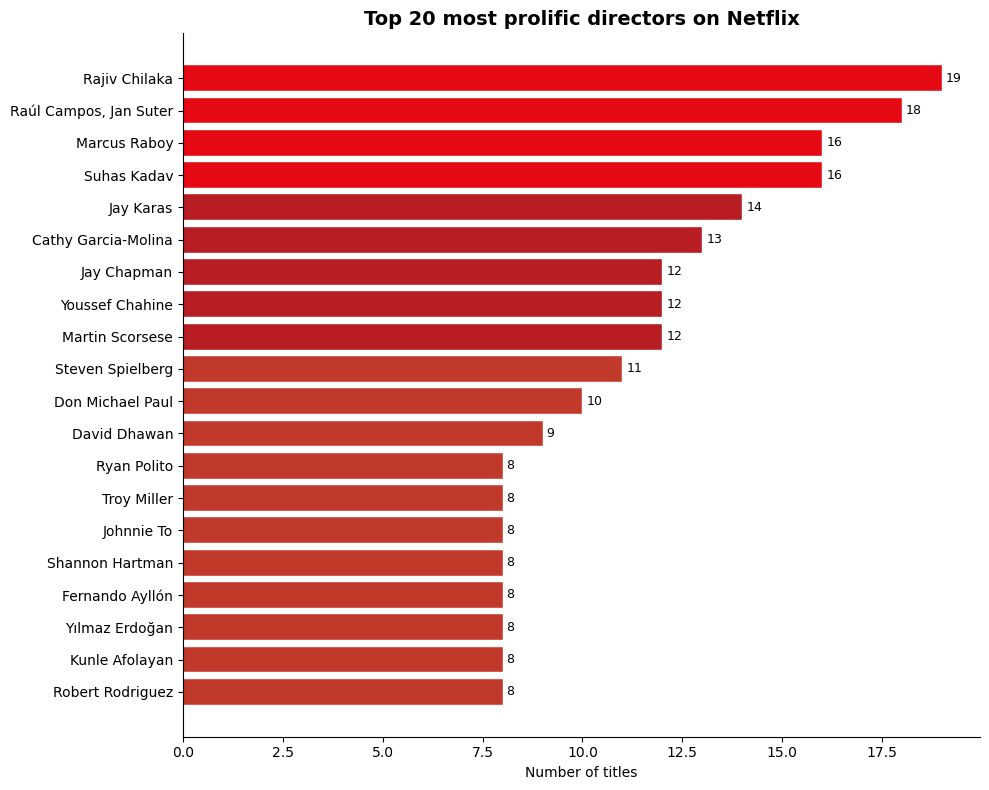

In [35]:
# Horizontal Bar (Top 20 directors)
top_directors = (df[df['director'] != 'Unknown']['director']
                 .value_counts().head(20)
                 .sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E50914' if v >= top_directors.max() * 0.8 else '#B81D24'
          if v >= top_directors.max() * 0.6 else '#c0392b'
          for v in top_directors.values]
bars = ax.barh(top_directors.index, top_directors.values,
               color=colors, edgecolor='white', linewidth=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
ax.set_title('Top 20 most prolific directors on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of titles'); ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.savefig('charts/11_bar_directors.png', dpi=150, bbox_inches='tight')
plt.show()

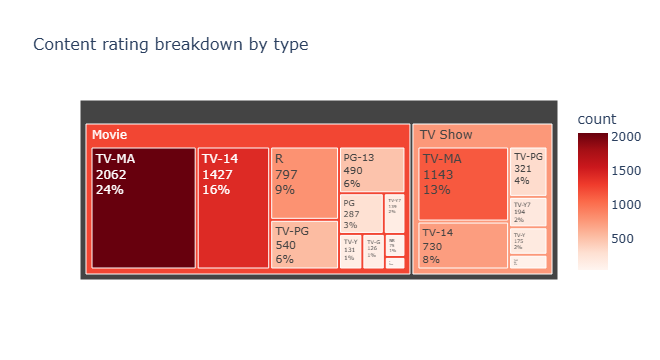

In [36]:
# Treemap (Rating × Type breakdown)
rating_type = (df.groupby(['rating', 'type'])
                 .size().reset_index(name='count'))
# Remove edge-case ratings with very low counts
rating_type = rating_type[rating_type['count'] > 5]

fig = px.treemap(
    rating_type,
    path=['type', 'rating'],
    values='count',
    color='count',
    color_continuous_scale='Reds',
    title='Content rating breakdown by type',
    hover_data={'count': True}
)
fig.update_traces(textinfo='label+value+percent root')
fig.update_layout(title_font_size=16)
fig.write_html('charts/12_treemap_ratings.html')
fig.show()

In [37]:
print("=" * 55)
print("FINAL ANALYSIS SUMMARY")
print("=" * 55)
print(f"\n1. CONTENT MIX")
print(f"   Movies: {len(movies)/len(df)*100:.1f}%  |  TV Shows: {len(shows)/len(df)*100:.1f}%")

print(f"\n2. TOP GENRE")
print(f"   {df_genres['genre'].value_counts().index[0]}",
      f"({df_genres['genre'].value_counts().iloc[0]:,} titles)")

print(f"\n3. TOP COUNTRY")
print(f"   {country_counts.iloc[0]['country']}",
      f"({country_counts.iloc[0]['count']:,} titles)")

print(f"\n4. PEAK GROWTH YEAR")
print(f"   {df['year_added'].value_counts().index[0]}")

print(f"\n5. MEDIAN MOVIE RUNTIME")
print(f"   {movies['duration_value'].median():.0f} minutes")

print(f"\n6. MOST PROLIFIC DIRECTOR")
directors = df[df['director'] != 'Unknown']['director'].value_counts()
print(f"   {directors.index[0]} ({directors.iloc[0]} titles)")

FINAL ANALYSIS SUMMARY

1. CONTENT MIX
   Movies: 69.7%  |  TV Shows: 30.3%

2. TOP GENRE
   International Movies (2,752 titles)

3. TOP COUNTRY
   United States (3,683 titles)

4. PEAK GROWTH YEAR
   2019

5. MEDIAN MOVIE RUNTIME
   98 minutes

6. MOST PROLIFIC DIRECTOR
   Rajiv Chilaka (19 titles)
